# Tâche 1 : Validation croisée selon les sites

## Contexte

Les données ABIDE proviennent de **plusieurs sites d'acquisition** (scanners, paramètres, populations différents). Ces différences inter-sites peuvent introduire des biais dans les modèles de machine learning : un modèle peut apprendre à reconnaître un site plutôt qu'une vraie signature biologique de l'autisme.

## Objectif

Comparer deux stratégies de validation croisée pour évaluer dans quelle mesure les performances du modèle reflètent une vraie capacité de classification vs. un artefact de site :

1. **Split-half stratifié par site** (*intra-site*) : les données d'entraînement et de test proviennent des **mêmes sites**, chaque site étant représenté proportionnellement dans les deux ensembles. On répète ce split 5 fois (5-fold) pour avoir une estimation stable.
2. **Leave-One-Site-Out (LOSO)** (*inter-site*) : à chaque fold, les données de test proviennent d'un **site entier jamais vu** à l'entraînement. C'est un test de généralisation beaucoup plus exigeant.

**Hypothèse** : si les performances chutent fortement en LOSO vs. intra-site, cela suggère que le modèle exploite les effets de site plutôt que des features neurobiologiques.

## Instructions de reproduction

Ce notebook suppose que les données ABIDE ont déjà été préparées. Voici les étapes :

```bash
# 1. Cloner le dépôt
git clone https://github.com/psy3019-6973-2026/Francois_Presentation_Projet_ABIDE-fMRI.git
cd Francois_Presentation_Projet_ABIDE-fMRI

# 2. Créer et activer l'environnement
conda env create -f environment.yml
conda activate env_abide

# 3. Préparer les données (~8h)
make prepare

# 4. Lancer ce notebook
cd notebook
jupyter notebook
```

Ce notebook utilise des **chemins relatifs** (`data/` et `output/`) afin d'être reproductible sur n'importe quelle machine.

## 1. Imports

In [2]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nilearn import datasets
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score
from sklearn.model_selection import LeaveOneGroupOut, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone

## 2. Chargement des données

In [3]:
# Chemins relatifs depuis le dossier du notebook
#project_root = Path.cwd().parent
#data_path = project_root / "output" / "ABIDE_BASC064_features.npz"
#data_dir  = project_root / "data"

project_root = Path("/mnt/d/udem/PSY3019/Francois_Presentation_Projet_ABIDE-fMRI")
data_path = project_root / "output" / "ABIDE_BASC064_features.npz"
data_dir = Path("/mnt/d/udem/PSY3019/PSY3019_abide_projet/data")

assert data_path.exists(), f"Fichier introuvable : {data_path}. Avez-vous exécuté prepare_data.py ?"

# Features
data = np.load(data_path, allow_pickle=True)
X = data["a"]

# Phénotype et étiquettes de site
abide = datasets.fetch_abide_pcp(
    data_dir=str(data_dir),
    pipeline="cpac",
    quality_checked=True
)
pheno = pd.DataFrame(abide.phenotypic)

y    = (pheno["DX_GROUP"] == 1).astype(int).to_numpy()  # 1=ASD, 0=TD
site = pheno["SITE_ID"].to_numpy()

# Vérifications de base
assert X.shape[0] == len(y) == len(site), "Désalignement entre X, y et site !"
print(f"X : {X.shape}  |  ASD : {y.sum()}  TD : {(y==0).sum()}")
print(f"Sites ({len(np.unique(site))}) : {np.unique(site)}")

[fetch_abide_pcp] Dataset found in /mnt/d/udem/PSY3019/PSY3019_abide_projet/data/ABIDE_pcp
X : (871, 2016)  |  ASD : 403  TD : 468
Sites (20) : ['CALTECH' 'CMU' 'KKI' 'LEUVEN_1' 'LEUVEN_2' 'MAX_MUN' 'NYU' 'OHSU' 'OLIN'
 'PITT' 'SBL' 'SDSU' 'STANFORD' 'TRINITY' 'UCLA_1' 'UCLA_2' 'UM_1' 'UM_2'
 'USM' 'YALE']


Le print ici montre :
Dans les données, un atlas de 64 régions a ete utiliser.
Pour chaque participant, on calcule la corrélation entre chaque paire de régions. 
Le nombre de paires possibles avec 64 régions c'est : 64 × 63 / 2 = 2016 connexions

Donc on a :
- 871 = nombre de participants
- 2016 = nombre de features (connexions cérébrales)

In [16]:
# Description des données

# Nombre de participants par site
print("Nombre de participants par site :")
site_counts = pd.Series(site).value_counts().sort_values()
print(site_counts)

# Nombre de participants et proportion ASD/TD par site
print("Composition par site :")
df_site = pd.DataFrame({"site": site, "ASD": y})
for s in sorted(np.unique(site)):
    mask = site == s
    n_total = mask.sum()
    n_asd = y[mask].sum()
    n_td = n_total - n_asd
    print(f"{s:12} | total={n_total:3d} | ASD={n_asd:3d} | TD={n_td:3d} | %ASD={n_asd/n_total*100:.0f}%")

Nombre de participants par site :
CMU          11
CALTECH      15
UCLA_2       21
OHSU         25
STANFORD     25
SBL          26
SDSU         27
LEUVEN_1     28
LEUVEN_2     28
OLIN         28
KKI          33
UM_2         34
YALE         41
TRINITY      44
MAX_MUN      46
PITT         50
UCLA_1       64
USM          67
UM_1         86
NYU         172
Name: count, dtype: int64
Composition par site :
CALTECH      | total= 15 | ASD=  5 | TD= 10 | %ASD=33%
CMU          | total= 11 | ASD=  6 | TD=  5 | %ASD=55%
KKI          | total= 33 | ASD= 12 | TD= 21 | %ASD=36%
LEUVEN_1     | total= 28 | ASD= 14 | TD= 14 | %ASD=50%
LEUVEN_2     | total= 28 | ASD= 12 | TD= 16 | %ASD=43%
MAX_MUN      | total= 46 | ASD= 19 | TD= 27 | %ASD=41%
NYU          | total=172 | ASD= 74 | TD= 98 | %ASD=43%
OHSU         | total= 25 | ASD= 12 | TD= 13 | %ASD=48%
OLIN         | total= 28 | ASD= 14 | TD= 14 | %ASD=50%
PITT         | total= 50 | ASD= 24 | TD= 26 | %ASD=48%
SBL          | total= 26 | ASD= 12 | TD= 14 | %

## 3. Définition du modèle

Une regression logistique (modèle linéaire simple) a été chosie.

### Vulgarisation :
**C'est quoi un modèle linéaire :**

Le modèle c'est la machine qui prédit ASD ou TD.

Ici, le modèle linéaire fait une addition pondérée des connexions avec le poids 
(connexion 1 × poids 1 + connexion 2 × poids 2 + connexion 3 × poids 3 + ...)


**C'est quoi une regression logistique :**

La régression logistique est un modèle linéaire, mais elle va 
une étape plus loin : elle transforme le score final en une 
probabilité entre 0 et 1.
- Proche de 1 = "probablement ASD"
- Proche de 0 = "probablement TD"

**qu'est ce qu'on obtient avec tout ca ?**

On obtient trois choses : 

1. **Accuracy** :
combien de fois le modele a eu juste

2. **Balanced accuracy** :
Par exemple, sur un groupe de 9 TD et 1 ASD, un modèle qui dit "tout le monde est TD" obtient 90% d'accuracy, mais il n'a détecté aucun ASD... :(
La balanced accuracy corrige ça en calculant séparément le taux de bonne détection chez les ASD, et le taux de bonne détection chez les TD
Puis elle fait la moyenne des deux.
Donc dans cet exemple, le modèle qui avant avait 90% d'accuracy en ignorant complètement les ASD obtient maintenant 50% (le niveau du hasard)

3. **ROC-AUC** :

La note qu'on donne au modèle après avoir regardé toutes ses prédictions à tous les seuils possibles.
- ROC-AUC = 0.5 → modèle nul (équivalent au hasard)
- ROC-AUC = 0.7 → correct 
- ROC-AUC = 1.0 → modèle parfait



In [10]:
base_model = Pipeline([
    ("scaler", StandardScaler()),
    # StandardScaler : remet toutes les connexions à la même échelle  pour que le modèle ne favorise pas une connexion juste parce 
    # que ses valeurs sont plus grandes

    ("clf",    LogisticRegression(max_iter=1000, random_state=42))
])
# LogisticRegression : 
# le modèle qui prédit ASD ou TD 
# max_iter=1000 : donne assez de tentatives au modèle pour trouver les meilleurs poids (2016 connexions = beaucoup de variables)
# random_state=42 : fixe le hasard 


Maintenant que nous avons fait la regression logistique, notre but est d'évaluer le modèle. C'est ce qu'on appelle la **validation croisée**

## 4. Validation croisée 1 : 5-Fold stratifié par site (intra-site)

Cette stratégie simule ce qui se passe quand on entraîne et teste sur les **mêmes sites**. Donc le modèle a déjà "vu" ces sites à l'entraînement.

Le 5-fold stratifié par site découpe chaque site en 5 groupes en s'assurant que chaque site est toujours représenté dans l'entraînement ET le test

Concrètement :

- On prend NYU → coupe en 5 groupes
- On prend CMU → coupe en 5 groupes
- On prend PITT → coupe en 5 groupes
- ...

Pourquoi 5 ?

Avec 1 seul fold → on test sur un groupe qui est peut-être facile ou difficile par hasard → résultat pas fiable

Avec 5 folds → on test sur 5 groupes différents → on fait la moyenne → résultat beaucoup plus stable et fiable

Note : pour les sites avec très peu de participants (ex: CALTECH, CMU), le nombre de folds est réduit  automatiquement pour éviter des groupes trop petits.


In [13]:
def kfold_within_site(X, y, site, n_splits=5, random_state=42):
    """
    Génère des folds train/test en stratifiant par site.
    Pour chaque fold, chaque site contribue proportionnellement
    au train et au test.
    Retourne une liste de tuples (train_idx, test_idx).
    """

    # Crée un dictionnaire vide pour stocker les folds de chaque site
    site_fold_indices = {s: [] for s in np.unique(site)}

    for s in np.unique(site):
        idx_s = np.where(site == s)[0]
        y_s   = y[idx_s]
   
        # Vérifie que le site a les deux classes (ASD et TD)
        if len(np.unique(y_s)) < 2:
            warnings.warn(
                f"Site '{s}' n'a qu'une seule classe ({np.unique(y_s)}) "
                f"et ne peut pas être stratifié. Il sera ignoré.",
                UserWarning
            )
            continue
       
        # Vérifie que la classe minoritaire a au moins 2 sujets
        min_class_count = np.bincount(y_s).min() 

        # Si le site a trop peu de sujets, on réduit le nombre de folds      
        if min_class_count < 2:
            warnings.warn(
                f"Site '{s}' : classe minoritaire = {min_class_count} sujet, "
                f"impossible de faire un split. Site ignoré.", UserWarning
            )
            continue

        effective_splits = min(n_splits, min_class_count)
        if effective_splits < n_splits:
            warnings.warn(
                f"Site '{s}' : classe minoritaire = {min_class_count} sujets, "
                f"n_splits réduit à {effective_splits}.", UserWarning
            )
       
        # Crée les folds pour ce site en respectant le ratio ASD/TD
        skf = StratifiedKFold(n_splits=effective_splits, shuffle=True, random_state=random_state)
        folds_s = [(idx_s[tr], idx_s[te]) for tr, te in skf.split(idx_s, y_s)]
        site_fold_indices[s] = folds_s

        # Garde uniquement les sites qui ont des folds valides
    valid_sites = [s for s in site_fold_indices if len(site_fold_indices[s]) > 0]
      
    # Assemble les folds de tous les sites ensemble
    folds = []
    for fold_i in range(n_splits):
        train_all, test_all = [], []
        for s in valid_sites:
            folds_s = site_fold_indices[s]
            fi = fold_i % len(folds_s)
            train_all.extend(folds_s[fi][0])
            test_all.extend(folds_s[fi][1])
        folds.append((np.array(train_all), np.array(test_all)))

    return folds


def evaluate_cv(folds, X, y, base_model):
    """
    Évalue le modèle sur une liste de folds (train_idx, test_idx).
    Retourne un DataFrame avec accuracy, balanced_accuracy et roc_auc par fold.
    """
    results = []
    for fold_i, (train_idx, test_idx) in enumerate(folds):
        model = clone(base_model)
        
        # Entraîne le modèle sur les données d'entraînement
        model.fit(X[train_idx], y[train_idx])

        # Prédit les étiquettes sur les données de test
        y_pred  = model.predict(X[test_idx])
        
        # Récupère les probabilités pour calculer le ROC-AUC
        y_score = model.predict_proba(X[test_idx])[:, 1]

        # ROC-AUC nécessite les deux classes dans le test
        # Si un fold de test ne contient que des ASD ou que des TD on peut pas calculer le ROC-AUC
        if len(np.unique(y[test_idx])) < 2:
            warnings.warn(f"Fold {fold_i} : une seule classe dans le test, ROC-AUC non calculé.", UserWarning)
            auc = np.nan
        else:
            auc = roc_auc_score(y[test_idx], y_score)

        results.append({
            "fold":              fold_i,
            "accuracy":          accuracy_score(y[test_idx], y_pred),
            "balanced_accuracy": balanced_accuracy_score(y[test_idx], y_pred),
            "roc_auc":           auc,
        })
    return pd.DataFrame(results)

In [14]:
folds_intra = kfold_within_site(X, y, site, n_splits=5)
results_intra = evaluate_cv(folds_intra, X, y, base_model)

print("=== Intra-site (5-fold stratifié par site) ===")
print(results_intra.round(3).to_string(index=False))
print("\nMoyenne :")
print(results_intra[["accuracy", "balanced_accuracy", "roc_auc"]].mean().round(3))

=== Intra-site (5-fold stratifié par site) ===
 fold  accuracy  balanced_accuracy  roc_auc
    0     0.710              0.704    0.748
    1     0.616              0.612    0.683
    2     0.672              0.671    0.729
    3     0.676              0.675    0.714
    4     0.593              0.593    0.641

Moyenne :
accuracy             0.654
balanced_accuracy    0.651
roc_auc              0.703
dtype: float64


### Interprétation des résultats intra-site :

Le modèle obtient une balanced accuracy de 0.651, ce qui veut dire que la regression logistique apprend quelque chose de réel, car il est bien au-dessus du hasard (0.5)

J'aurai penser que le modèle serait meilleur puisqu'il connaît déjà les sites, mais il obtient seulement 65% parce que le modèle voit les mêmes sites mais pas les mêmes personnes, il doit toujours généraliser à de nouveaux participants. 
Cela montre que le signal biologique de l'autisme dans la connectivité cérébrale doit etre faible.

Les 5 folds donnent des scores qui varient entre 0.593 et 0.7, ce qui montre que le résultat dépend du groupe testé 


## 5. Validation croisée 2 : Leave-One-Site-Out (LOSO)

Contrairement au 5-fold intra-site, le LOSO teste le modèle sur des sites qu'il a jamais vus à l'entraînement

Concrètement, avec 20 sites :
- Itération 1 : entraîne sur 19 sites, teste sur CALTECH
- Itération 2 : entraîne sur 19 sites, teste sur CMU
- ...
- Itération 20 : entraîne sur 19 sites, teste sur YALE

Comme on a 20 sites, on répète 20 fois (une itération par site)

Le but c'est de simuler ce qui se passerait si on appliquait le modèle à un nouvel hôpital inconnu.
On veut donc repondre a la question : 
est-ce que le modèle généralise bien à des données qu'il n'a jamais vues ?


In [15]:
# Crée l'objet LOSO va générer une itération par site
logo = LeaveOneGroupOut()
results_loso = []

# Boucle principale (à chaque itération un site différent est mis de côté pour le test)
for train_idx, test_idx in logo.split(X, y, groups=site):
    site_test = np.unique(site[test_idx])[0] # Identifie quel site est testé dans cette itération
    model = clone(base_model)  # réinitialisation 
    model.fit(X[train_idx], y[train_idx]) # Entraîne le modèle sur les 19 autres sites
    y_pred  = model.predict(X[test_idx]) # Prédit ASD ou TD sur le site de test (jamais vu à l'entraînement)
    y_score = model.predict_proba(X[test_idx])[:, 1] # Récupère les probabilités pour calculer le ROC-AUC

    # on calcule pas le ROC-AUC si le site de test a qu'une seule classe (que ASD ou que TD)    
    if len(np.unique(y[test_idx])) < 2:
        warnings.warn(f"Site '{site_test}' : une seule classe dans le test, ROC-AUC non calculé.", UserWarning)
        auc = np.nan
    else:
        auc = roc_auc_score(y[test_idx], y_score)

    results_loso.append({
        "site":              site_test,
        "n_test":            len(test_idx),
        "accuracy":          accuracy_score(y[test_idx], y_pred),
        "balanced_accuracy": balanced_accuracy_score(y[test_idx], y_pred),
        "roc_auc":           auc,
    })

results_loso = pd.DataFrame(results_loso).sort_values("balanced_accuracy", ascending=False) # Trie du meilleur au moins bon

print("=== LOSO — résultats par site ===")
print(results_loso.round(3).to_string(index=False))
print("\nMoyenne (pondérée par n_test) :")

# Moyenne pondérée par le nombre de participants car les grands sites comptent plus que les petits
weights = results_loso["n_test"] / results_loso["n_test"].sum()
for col in ["accuracy", "balanced_accuracy", "roc_auc"]:
    val = (results_loso[col] * weights).sum()
    print(f"  {col}: {val:.3f}")

=== LOSO — résultats par site ===
    site  n_test  accuracy  balanced_accuracy  roc_auc
LEUVEN_1      28     0.750              0.750    0.663
LEUVEN_2      28     0.750              0.740    0.740
    PITT      50     0.740              0.737    0.777
    SDSU      27     0.778              0.734    0.796
    UM_1      86     0.733              0.723    0.800
     USM      67     0.687              0.719    0.787
    OLIN      28     0.714              0.714    0.740
    UM_2      34     0.735              0.712    0.835
    YALE      41     0.707              0.709    0.833
     KKI      33     0.667              0.685    0.730
     NYU     172     0.634              0.654    0.725
     CMU      11     0.636              0.633    0.700
 TRINITY      44     0.591              0.621    0.703
  UCLA_1      64     0.609              0.617    0.717
     SBL      26     0.615              0.613    0.554
  UCLA_2      21     0.619              0.609    0.709
STANFORD      25     0.600     

### Interprétation des résultats LOSO :
Nous voulions répondre a la question : 

Est-ce que le modèle généralise bien à des données qu'il n'a jamais vues ?
Et bien cela **dépend du site**


Sites qui généralisent le mieux : LEUVEN_1, LEUVEN_2, PITT → balanced accuracy de 0.737 a 0.750
→ Le modèle arrive à prédire ASD vs TD même sans avoir vu ces sites

Sites qui sont dans le seuil du hasard : OHSU, CALTECH, MAX_MUN (balanced accuracy inferieur à 0.5)
→ Le modèle échoue complètement sur ces sites (pourquoi ?)


 **Note:**
 J'ai regardé la descriptons des sites où le seuils est inferieur au hasard
- OHSU (n=25, 48% ASD)
- CALTECH (n=15, 33% ASD)
- MAX_MUN (n=46, 41% ASD)
 
La proportion ASD/TD est raisonnable pour les trois sites. Donc l'échec de généralisation n'est pas dû à un déséquilibre des classes

C'est probablement un effet de site (des caractéristiques d'acquisition différentes que le modèle ne reconnaît pas)

Pour CALTECH avec un n=15, le résultat est aussi peu fiable statistiquement





## 6. Comparaison visuelle des deux stratégies

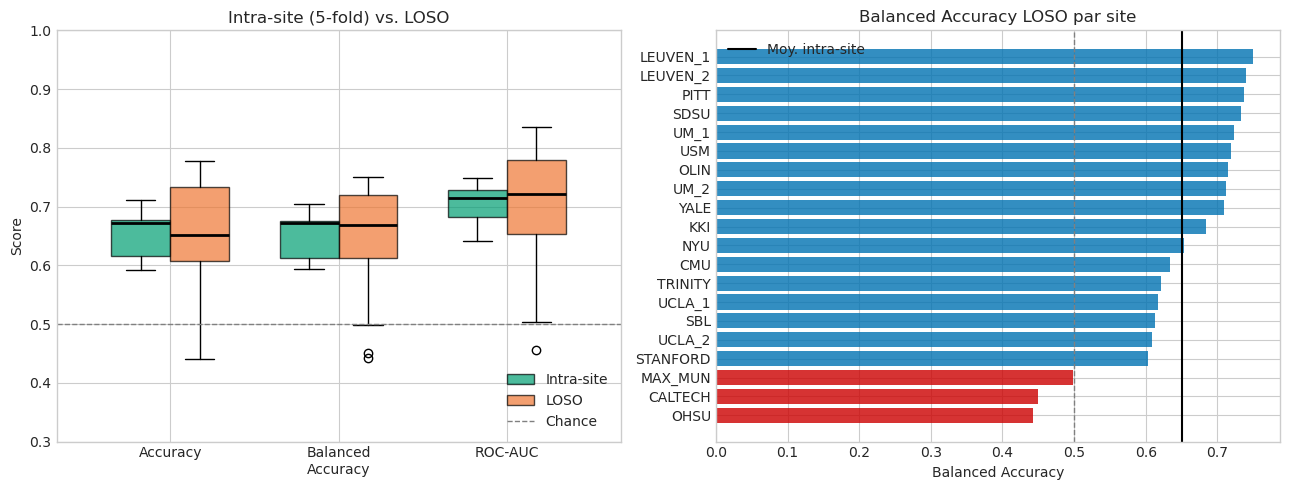

Figure sauvegardée : comparaison_cv.png


In [32]:
# Palette daltonien-friendly 
COLOR_INTRA = "#009E73"  # vert pour intra
COLOR_LOSO  = "#EE7733"  # orange pour LOSO

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

##### Panneau gauche : boxplot comparatif 
metrics = ["accuracy", "balanced_accuracy", "roc_auc"]
labels  = ["Accuracy", "Balanced\nAccuracy", "ROC-AUC"]

intra_vals = [results_intra[m].dropna().values for m in metrics]
loso_vals  = [results_loso[m].dropna().values  for m in metrics]

x = np.arange(len(metrics))
width = 0.35

# Boxplot intra-site
bp1 = axes[0].boxplot(intra_vals, positions=x - width/2, widths=width,
                       patch_artist=True, 
                       boxprops=dict(facecolor=COLOR_INTRA, alpha=0.7),
                       medianprops=dict(color="black", linewidth=2))

# Boxplot LOSO 
bp2 = axes[0].boxplot(loso_vals,  positions=x + width/2, widths=width,
                       patch_artist=True, 
                       boxprops=dict(facecolor=COLOR_LOSO, alpha=0.7),
                       medianprops=dict(color="black", linewidth=2))

# Ligne pointillée = niveau du hasard (0.5)
axes[0].axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Chance (0.5)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel("Score")
axes[0].set_title("Intra-site (5-fold) vs. LOSO")
axes[0].legend([bp1["boxes"][0], bp2["boxes"][0], axes[0].lines[-1]],
               ["Intra-site", "LOSO", "Chance"],
               loc="lower right")
axes[0].set_ylim(0.3, 1.0)

##### Panneau droit : balanced_accuracy LOSO par site
# Rouge = en dessous du hasard, Bleu = au dessus du hasard
loso_sorted = results_loso.sort_values("balanced_accuracy")
colors_site = ["#CC0000" if v < 0.5 else "#0072B2" 
               for v in loso_sorted["balanced_accuracy"]]

axes[1].barh(loso_sorted["site"], loso_sorted["balanced_accuracy"], 
             color=colors_site, alpha=0.8)
axes[1].axvline(0.5, color="gray", linestyle="--", linewidth=1)

# Ligne verticale = moyenne intra-site pour comparaison
axes[1].axvline(results_intra["balanced_accuracy"].mean(), color="black",
                linestyle="-", linewidth=1.5, label="Moy. intra-site")
axes[1].set_xlabel("Balanced Accuracy")
axes[1].set_title("Balanced Accuracy LOSO par site")
axes[1].legend()

plt.tight_layout()
plt.savefig("comparaison_cv.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardée : comparaison_cv.png")

La figure 2 illustre l'hétérogénéité inter-site : 3 sites sur 20 (MAX_MUN, CALTECH, OHSU) obtiennent une balanced accuracy inférieure à 0.5 en LOSO, soit en dessous du niveau du hasard, tandis que la majorité des sites dépasse la moyenne intra-site.

## 7. Discussion

### Résumé des résultats

| Stratégie | Balanced Accuracy (moy.) | ROC-AUC (moy.) |
|---|---|---|
| Intra-site (5-fold) | *0.651* | *0.703* |
| LOSO | *0.661* | *0.718* |

### Interprétation

Je m'attendais a ce que le modèle apprenne surtout la signature des scanners (Intra-site elevé et LOSO bas). Mais ce n'est pas ce qu'on observe :

**Au niveau global (moyenne des 20 sites) :**
On n'observe pas d'effet de site dominant (LOSO et intra-site sont presque egaux)

Mais ce résultat est à interpréter avec prudence : certains petits sites (CALTECH, CMU) n'avaient que 2 folds effectifs, ce qui a peut-être sous-estimé le score intra-site

**Au niveau individuel (site par site) :**
Fort effet de site pour certains sites :
- OHSU, CALTECH, MAX_MUN échouent complètement
- LEUVEN_1, LEUVEN_2, PITT performent bien (0.737 à 0.750)

La moyenne **cache** la variabilité 





